In [1]:
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

In [ ]:
cache_session = requests_cache.CachedSession('data/weather_cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "hourly": ["temperature_2m", "relative_humidity_2m", "surface_pressure"],
    "timezone": "Asia/Kolkata"
}

response = openmeteo.weather_api(url=url, params=params)[0]
hourly = response.Hourly()

In [10]:
print(hourly.Time())

1672511400


In [3]:
df = pd.DataFrame({
    "date": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "temperature": hourly.Variables(0).ValuesAsNumpy(),
    "humidity": hourly.Variables(1).ValuesAsNumpy(),
    "pressure": hourly.Variables(2).ValuesAsNumpy()
}).set_index("date").dropna()

In [11]:
df

,temperature,humidity,pressure
date,,,
2022-12-31 18:30:00+00:00,9.15,90.336136,993.987244
2022-12-31 19:30:00+00:00,8.75,91.237335,993.950623
2022-12-31 20:30:00+00:00,8.20,92.143257,993.608337
2022-12-31 21:30:00+00:00,7.90,93.078575,993.386169
2022-12-31 22:30:00+00:00,7.85,93.395767,993.381470
...,...,...,...
2023-12-31 13:30:00+00:00,11.10,88.076714,992.895691
2023-12-31 14:30:00+00:00,10.20,91.333176,993.107422
2023-12-31 15:30:00+00:00,9.30,93.786438,993.026245


In [4]:
df.isnull().sum()

temperature    0
humidity       0
pressure       0
dtype: int64

In [6]:
df.shape

(8760, 3)

Text(0.5, 0, 'humidity in %')

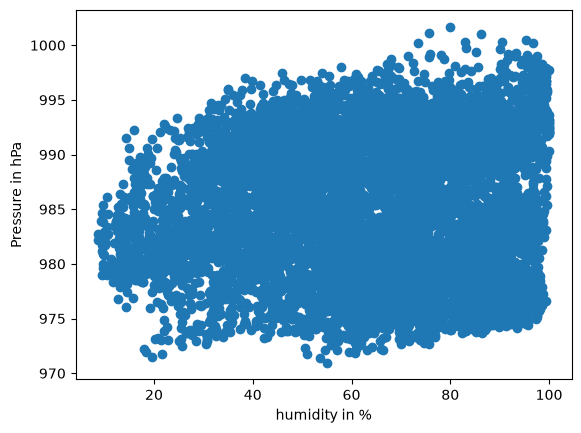

In [8]:
import matplotlib.pyplot as plt
plt.scatter(df['humidity'], df['pressure'])
plt.ylabel("Pressure in hPa")
plt.xlabel("humidity in %")

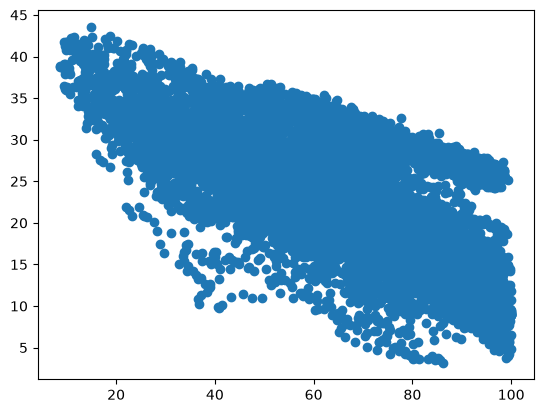

In [7]:
plt.scatter(df['humidity'], df['temperature'])

Text(0.5, 0, 'Temperature')

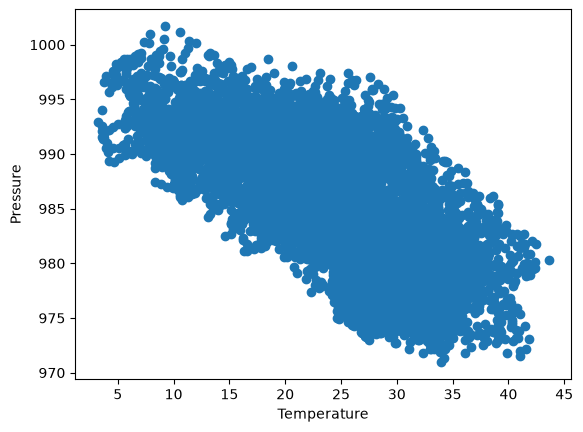

In [12]:
plt.scatter(df['temperature'], df['pressure'])
plt.ylabel("Pressure")
plt.xlabel("Temperature")